#**System Simulation: Event-Driven Models**

```
INF301 – System Modeling and Simulation
Prof. Luiz Henrique Bonani
Week 08
```

# Discrete Event Models
Models that are temporally oriented characterize systems in which signals appear synchronously at regular times.
Event-driven models behave asynchronously and generally have very simple signals that occur at irregular (and sometimes random) times.
In event-driven models, the characteristics are statistical in nature. For example, in digital communications, when each message arrives, the size of the message and how long it remains in the system are also random variables.

Typically, arrival events occur at times $t_0$, $t_1$, $t_2$, ..., where $t_0 = 0$ is the reference, and are queued using a FIFO (First In First Out) queue.

Thus, the system introduces a wait before each message is processed.

The processing time or service time is usually statistically distributed, but this statistic is known.


# Simulation Diagrams

Discrete event models can be described by their respective diagrams, such as the event sequencer, the queue, the server, the collector, and the distributor.

<center>

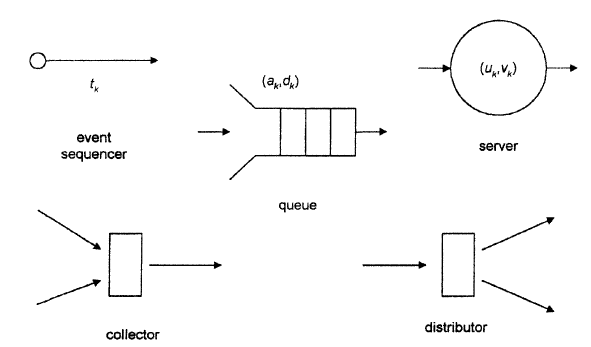
</center>

# Simulation Structures

Events are often referred to as clients, since they represent individuals who, for example, wait in a bank queue until they are served. This scenario is a valuable analogy, and simulation diagrams provide structures to support it.

Upon arrival, each client enters a queue, where the first client to arrive is the first to be served. The representation of a queue requires a vector of ordered pairs $Q = [(a_1, d_1), (a_2, d_2), ..., (a_n, d_n)]$, in which $a_k$ is the time of entry into the queue and $d_k$ is the time of exit from the queue for event $k$.

Another structure is the server, which can be understood as a device that effectively performs the operations on a message or a client. Servers can serve only one client at a time, and during this time, they remain in the “busy” state. If it is not “busy”, the server is in the “available” state (free).

Interfaces between sequencers, queues, and servers are also needed. These include distributors, which disperse events to different servers, and collectors, which can aggregate events after a server has serviced them.

## Example 1

Consider an M/M/1* queuing system, in which data packets of different sizes arrive at random times at a single server. The server forwards the packets along the communication network. Note the similarity between this problem and a drive-through system at a fast-food restaurant. Model this system and show the results for an average arrival rate λ of 3 messages per minute, with a mean time τ of each message being 2 minutes.

**Kendall notation:**

**A/B/K**,

where **A** and **B** are the probability distributions of arrival time and service time. (**M** for exponential and **D** for deterministic);

**K** is the number of servers in parallel.

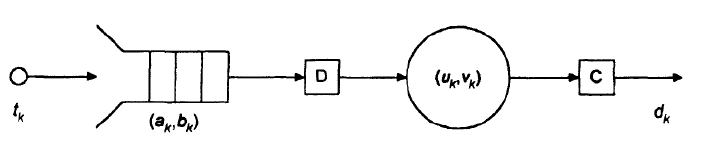

Here, $u_k$ are the entry times and $v_k$ are the exit times.

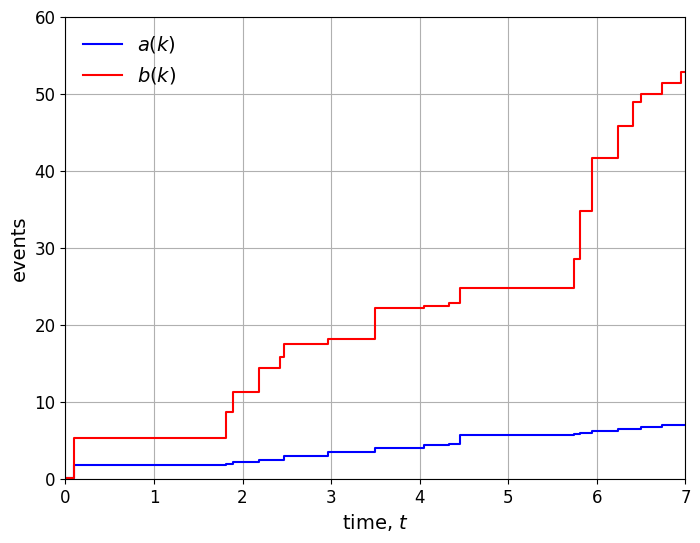

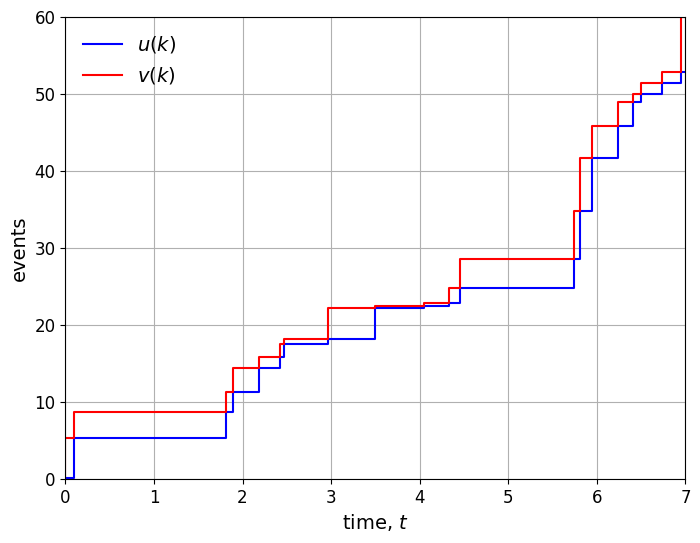

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
n = 25;
n = n + 1; tau = 2;
t = np.zeros(n); v = np.zeros(n); d = np.zeros(n)
a = np.zeros(n); b = np.zeros(n); u = np.zeros(n)
lbd = 3; mu = 1/tau

for k in range(1,n):
    t[k] = t[k-1] - 1/lbd*np.log(1.0 - np.random.random_sample())
    a[k] = t[k]
    r = np.random.random_sample()
    if (t[k] > v[k-1]): # server free
        b[k] = t[k]
        u[k] = t[k]
        v[k] = t[k] - 1/mu*np.log(1.0-r)
    else: # server busy
        b[k] = v[k-1]
        u[k] = v[k-1]
        v[k] = v[k-1] - 1/mu*np.log(1.0-r)
    d[k] = v[k]

Q = b - a
S = v - u
T = d - t

# Figures
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.step(t, a,"b-", label=r"$a(k)$")
plt.step(t, b,"r-", label=r"$b(k)$")
plt.xlabel("time, $t$",fontsize=14)
plt.ylabel("events",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis(tuple([0, 7, 0, 60]))
plt.grid()
plt.show()

fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.step(t, u,"b-", label=r"$u(k)$")
plt.step(t, v,"r-", label=r"$v(k)$")
plt.xlabel("time, $t$",fontsize=14)
plt.ylabel("events",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis(tuple([0, 7, 0, 60]))
plt.grid()
plt.show()

# Example 2: M/M/2 System

Simulate an M/M/2 system, which has 2 servers to serve customers.

<center>

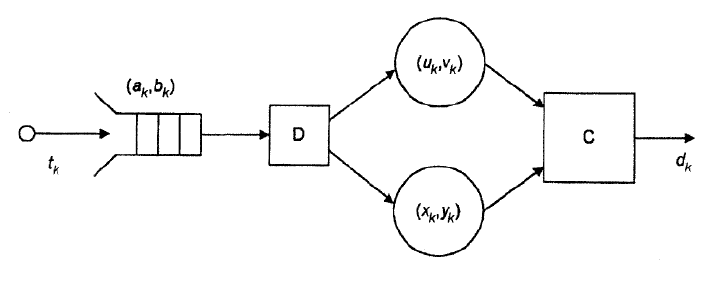
</center>

**Solution**:

The main difference in the implementation of an M/M/2 system is in the distributor and collector protocol, which can be implemented according to the following algorithm:

<center>

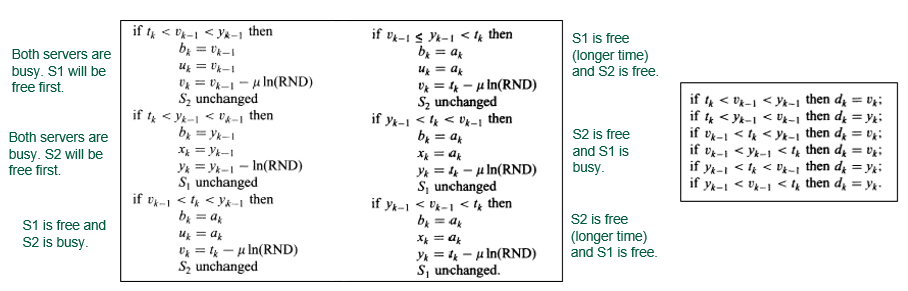

</center>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
n = 20;
n = n + 1; tau = 2;
t = np.zeros(n+1); st = np.zeros(n+1);
u = np.zeros(n+1); v = np.zeros(n+1); # server 1 (s1)
x = np.zeros(n+1); y = np.zeros(n+1); # server 2 (s2)
a = np.zeros(n+1); b = np.zeros(n+1);
d = np.zeros(n+1)
sBy = np.zeros(n+1)
lbd = 3; mu = 1/tau

for k in range(1,n):
    t[k] = t[k-1] - 1/lbd*np.log(1.0 - np.random.random_sample())
    a[k] = t[k]
    r = np.random.random_sample()
    s = - 1/mu*np.log(1.0-r)
    if (t[k] < v[k-1] and v[k-1] < y[k-1]): # both servers are busy
      b[k] = v[k-1]                         # s1 will be free first
      u[k] = v[k-1]
      v[k] = v[k-1] + s
      x[k] = x[k-1]; y[k] = y[k-1] # server 2 will remain in the same state
      d[k] = v[k]
      sBy[k] = 1
    elif (t[k] < y[k-1] and y[k-1] < v[k-1]): # both servers are busy
      b[k] = y[k-1]                         # s2 will be free first
      x[k] = y[k-1]
      y[k] = y[k-1] + s
      u[k] = u[k-1]; v[k] = v[k-1] # server 1 will remain in the same state
      d[k] = y[k]
      sBy[k] = 2
    elif (v[k-1] < t[k] and t[k] < y[k-1]): # s1 is free and s2 is busy
      b[k] = a[k-1]
      u[k] = a[k-1]
      v[k] = t[k] + s
      x[k] = x[k-1]; y[k] = y[k-1] # server 2 will remain in the same state
      d[k] = v[k]
      sBy[k] = 1
    elif (v[k-1] <= y[k-1] and y[k-1] < t[k]): # s1 is free and s2 is free
      b[k] = a[k]                           # s1 is free for a longer time
      u[k] = a[k]
      v[k] = t[k] + s
      x[k] = x[k-1]; y[k] = y[k-1] # server 2 will remain in the same state
      d[k] = v[k]
      sBy[k] = 1
    elif (y[k-1] < t[k] and t[k] < v[k-1]): # s2 is free and s1 is busy
      b[k] = a[k]
      x[k] = a[k]
      y[k] = t[k] + s
      u[k] = u[k-1]; v[k] = v[k-1] # server 1 will remain in the same state
      d[k] = y[k]
      sBy[k] = 2
    elif (y[k-1] < v[k-1] and v[k-1] < t[k]): # s1 is free and s2 is free
      b[k] = a[k]                           # s2 is free for a longer time
      x[k] = a[k]
      y[k] = t[k] + s
      u[k] = u[k-1]; v[k] = v[k-1] # server 1 will remain in the same state
      d[k] = y[k]
      sBy[k] = 2
    st[k] = s

print(" k    st      t[k]    a[k]    b[k]    u[k]    v[k]    x[k]    y[k]    d[k]   Served by:")
print(" -------------------------------------------------------------------------------------")
for k in range(n):
   line = [k, st[k], t[k], a[k], b[k], u[k], v[k], x[k], y[k], d[k], int(sBy[k])]
   print('{:>2}   {:>5.2f}   {:>5.2f}   {:>5.2f}   {:>5.2f}   {:>5.2f}   {:>5.2f}   {:>5.2f}   {:>5.2f}   {:>5.2f}   {:>2}'.format(*line))

 k    st      t[k]    a[k]    b[k]    u[k]    v[k]    x[k]    y[k]    d[k]   Served by:
 -------------------------------------------------------------------------------------
 0    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0
 1    0.67    0.04    0.04    0.04    0.04    0.71    0.00    0.00    0.71    1
 2    1.94    0.57    0.57    0.57    0.04    0.71    0.57    2.51    2.51    2
 3    0.35    1.02    1.02    0.57    0.57    1.37    0.57    2.51    1.37    1
 4    1.15    1.38    1.38    1.02    1.02    2.53    0.57    2.51    2.53    1
 5    3.23    1.59    1.59    2.51    1.02    2.53    2.51    5.74    5.74    2
 6    0.36    1.90    1.90    2.53    2.53    2.89    2.51    5.74    2.89    1
 7    0.21    2.11    2.11    2.89    2.89    3.10    2.51    5.74    3.10    1
 8    6.18    2.17    2.17    3.10    3.10    9.28    2.51    5.74    9.28    1
 9    2.57    2.59    2.59    5.74    3.10    9.28    5.74    8.31    8.31    2
10    1.54    2.69    2.6

It’s worth noting that the events do not exit the system in the same order that they have entered.

# Queuing Theory
There is a special event-oriented model. This structure is the standard queue, in which customers line up to wait for service and wait again while they are being served.

These queues, of which the M/M/1 and M/M/2 systems are examples, can always be simulated. However, if the statistics of arrival and service times are well known, there are also closed analytical solutions for these problems. This theory is called Queuing Theory.

Queuing Theory describes the behavior of waiting lines. The occurrence of events is characterized by the arrival rate, $\lambda$, and it defines whether the system will be stable or not. In the case of unstable systems, where the queue size can grow indefinitely, adjustments to the design are necessary.

These adjustments may include increasing the number of servers (cost) or blocking new arrivals (lack of service). Clients, when queued, wait for service at one of the m servers. After waiting in the queue for time $Q_k$, the selected server then serves the client for a service time $S_k$.
The service time is characterized by having an average of $\tau$ time units per client. Equivalently, there are $\mu= 1/\tau$ clients per time unit served by the servers.

<center>

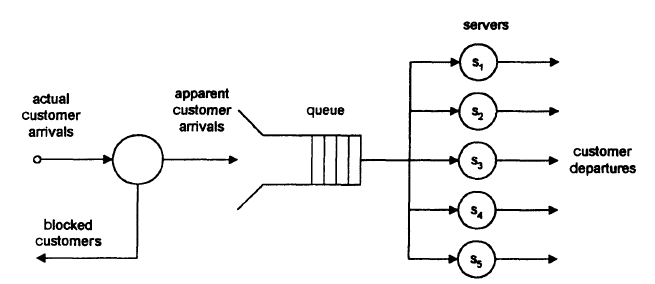
</center>

Furthermore, $T_k$ represents the total time each client spends in the system. Thus, since these are random variables, we can write $E[T_k] = E[Q_k] + E[S_k]$.

By analyzing the arrivals $A(t)$ and the departures $D(t)$ and plotting the graph of their evolution, one can conclude that the number of customers in the system is equal to the area between the arrival and departure curves.

It should be clear that the area marked to the left of time $t$ is equal to the area below customer $k$.

<center>

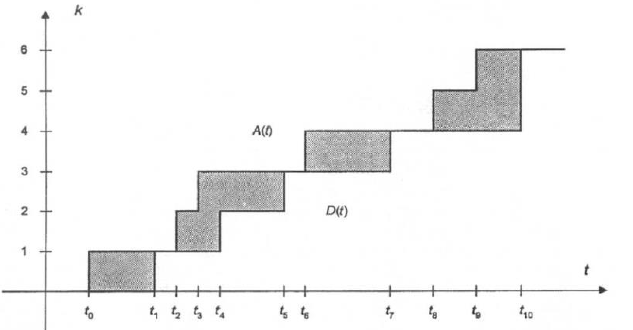
</center>

<center>

|   View |  Nomenclature | Definition | Interpretation |
|:-------|:-------------:|:----------:|:--------------:|
| System | $\bar{N}$     | $\langle T(t) \rangle$   | Mean number of customers in system  |
|        | $\bar{L}$     | $\langle Q(t) \rangle$   | Mean number of customers waiting in queue  |
|        | $\rho$     | $\langle S(t) \rangle$   | Mean number of customers being served  |
| Customer  | $\bar{T}$     | $E[T_k]$   | Mean time each customer is in system  |
|        | $\bar{Q}$     | $E[Q_k]$   | Mean time each customer is in queue  |
|        | $\tau$     | $E[S_k]$   | Mean time for each customer to be served  |
</center>

Thus,

$$ T(t)=\sum_{i=1}^{A(t)} T_{i} \quad \text { and } \quad E\left[T_{k}\right]=\frac{1}{A(t)} \sum_{i=1}^{A(t)} T_{i} $$

Assuming that the arrival rate is constant:

$$ \lambda \approx \frac{A(t)}{t} $$

And following the reasoning:

$$ \langle T(t)\rangle=\frac{1}{t} \int_{0}^{1}[A(t)-D(t)] d t=\frac{1}{t} \sum_{i=1}^{A(t)} T_{i}=\frac{A(t)}{t} \frac{1}{A(t)} \sum_{i=1}^{A(t)} T_{i}=\lambda E\left[T_{k}\right] $$

This last result is known as Little's Formula. It expresses the duality between the system and customer points of view of any queuing system, regardless of the nature of its statistics.

Using the same nomenclature introduced previously, $E[N] = \lambda E[T]$ and $E[L] = \lambda E[Q]$.

These systems are modeled with utilization rate $\rho = \lambda/\mu = \lambda \tau$.

For convergence reasons, the system utilization should always be kept less than 1.

# Equations for the M/M/1 System

The calculation of the average number of customers in the system at any time is given by:

$$ \begin{aligned} \bar{N} \equiv\langle T(t)\rangle &=\sum_{k=0}^{\infty} k \operatorname{Pr}[T(t)=k]=\sum_{k=0}^{\infty} k(1-\rho) \rho^{k}=\rho(1-\rho) \sum_{k=0}^{\infty} \frac{d}{d \rho} \rho^{k} =\frac{\rho}{1-\rho}=\frac{\lambda}{\mu-\lambda} \end{aligned} $$

Applying Little's Theorem:

$$ \bar{T}=\frac{1}{\lambda} \bar{N}=\frac{1}{\lambda} \frac{\lambda}{\mu-\lambda}=\frac{1}{\mu-\lambda}=\frac{\tau}{1-\lambda \tau} $$

And given that $E[Q] = E[T] – \tau$:

$$ \bar{Q}=\bar{T}-\tau=\frac{\tau}{1-\lambda \tau}-\tau=\frac{\lambda}{\mu(\mu-\lambda)}=\frac{\lambda \tau^{2}}{1-\lambda \tau} $$

## Example 3

Consider a data communication system in which messages are transmitted as Poisson processes at a rate of 100 messages per hour. Messages are processed with an average time of 30 seconds. Describe the behavior of this system analytically and using a simulation. Compare the results obtained.

**Solution**:

Pay special attention to the units. For this example, you can use the same script used in Example 1, conveniently changing the values ​​of $\lambda$ to $100/60$. Here, $\tau = 0.5$ minute. Thus: $\mu = 1/\tau = 2$ minutes.



q =  0.08949039465119699 , Qa =  2.500000000000001 , tt =  0.47553403701705127 , Ta =  3.000000000000001  s =  0.38604364236585426


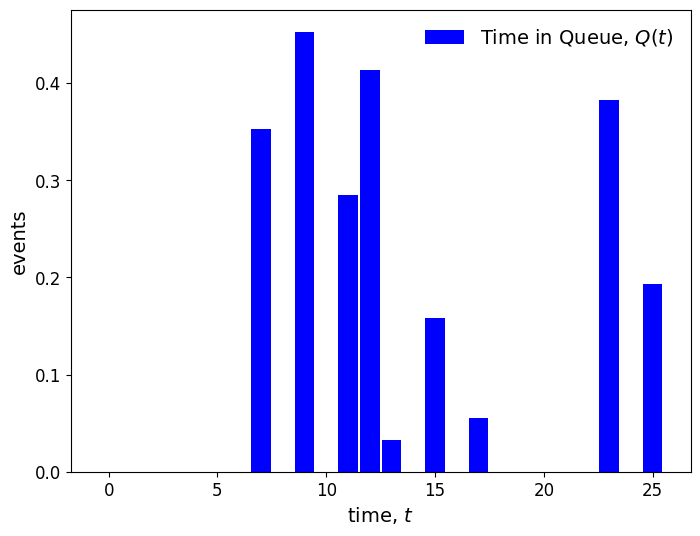

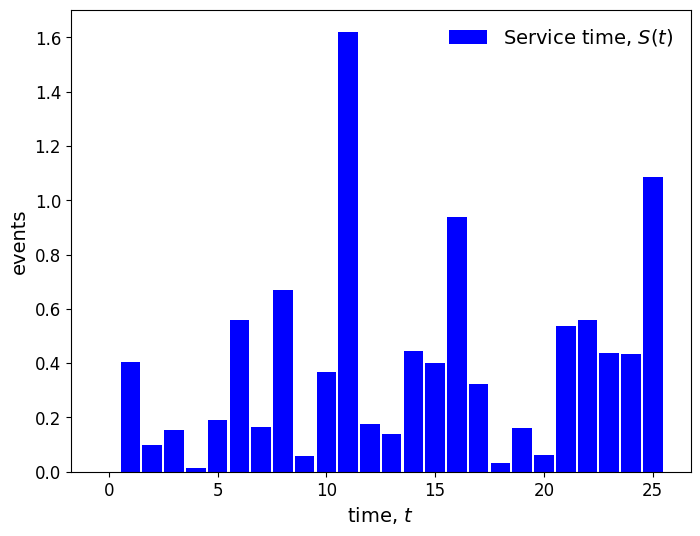

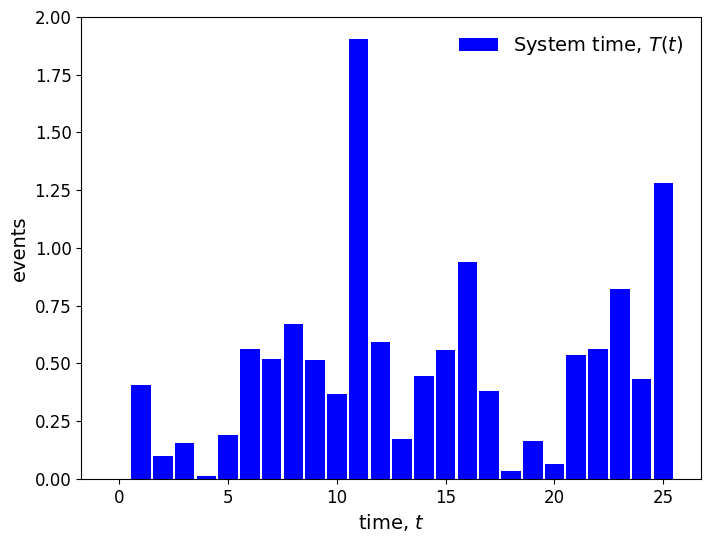

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
n = 25;
n = n + 1
t = np.zeros(n); v = np.zeros(n); d = np.zeros(n)
a = np.zeros(n); b = np.zeros(n); u = np.zeros(n)
lbd = 100/60; mu = 2

for k in range(1,n):
    t[k] = t[k-1] - 1/lbd*np.log(1.0 - np.random.random_sample())
    a[k] = t[k]
    r = np.random.random_sample()
    if (t[k] > v[k-1]): # free server
        b[k] = t[k]
        u[k] = t[k]
        v[k] = t[k] - 1/mu*np.log(1.0-r)
    else: # busy server
        b[k] = v[k-1]
        u[k] = v[k-1]
        v[k] = v[k-1] - 1/mu*np.log(1.0-r)
    d[k] = v[k]

Q = b - a
S = v - u
T = d - t

q = np.mean(Q)
Qa = lbd/(mu*(mu-lbd))
tt = np.mean(T)
Ta = 1/(mu-lbd)
s = np.mean(S)

print("q = ",q,", Qa = ",Qa,", tt = ",tt,", Ta = ", Ta," s = ",s)

# Figures
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.bar(range(len(Q)), Q, color = "blue", width=0.9, align="center", label=r"Time in Queue, $Q(t)$")
plt.xlabel("time, $t$",fontsize=14)
plt.ylabel("events",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.show()

fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.bar(range(len(S)), S, color = "blue", width=0.9, align="center", label=r"Service time, $S(t)$")
plt.xlabel("time, $t$",fontsize=14)
plt.ylabel("events",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.show()

fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.bar(range(len(T)), T, color = "blue", width=0.9, align="center", label=r"System time, $T(t)$")
plt.xlabel("time, $t$",fontsize=14)
plt.ylabel("events",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.show()

Let's increase the number of events...

q =  2.9445611697641447 , Qa =  2.500000000000001 , tt =  3.4478039755700594 , Ta =  3.000000000000001  s =  0.5032428058059142


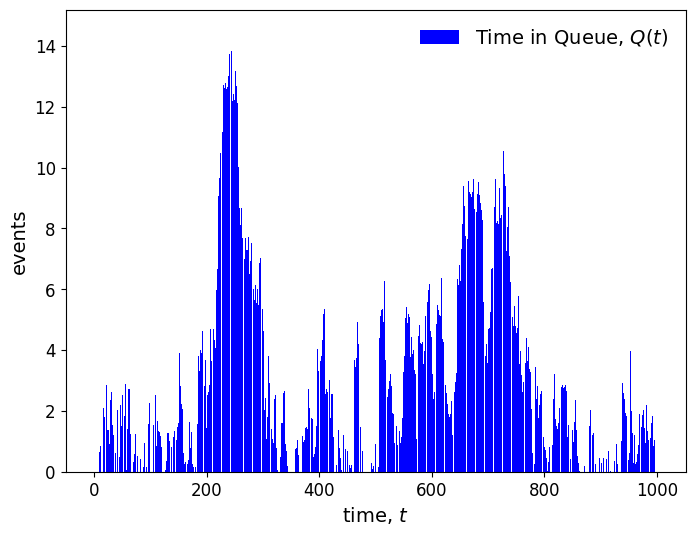

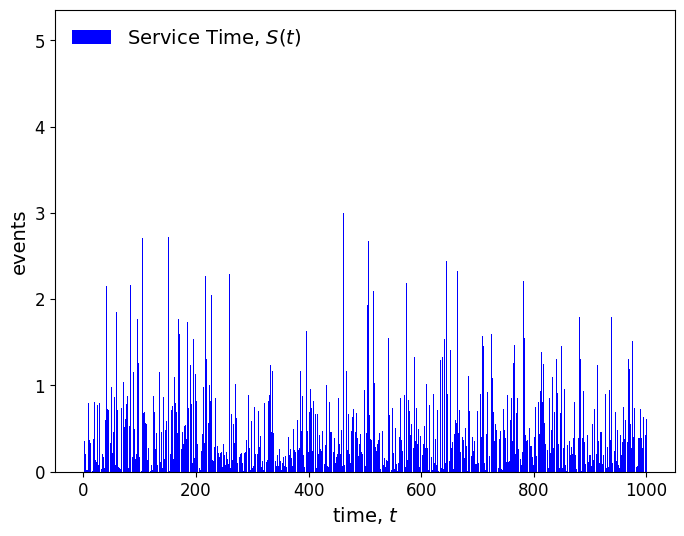

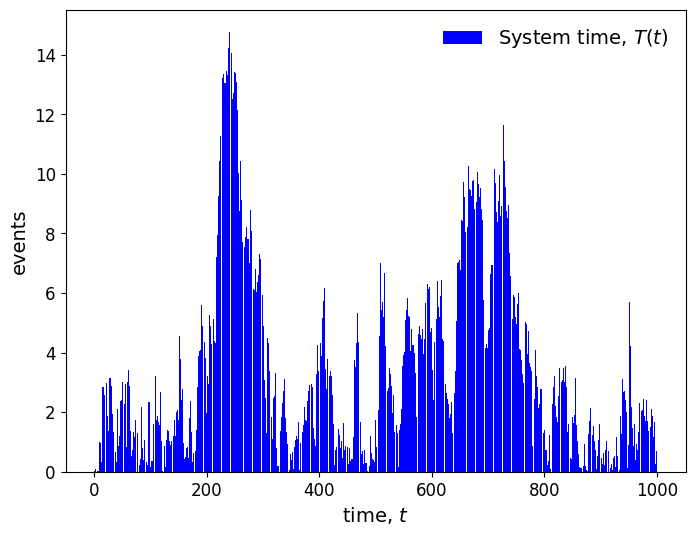

In [ ]:
# increasing the number of events from 25 to 10000

import numpy as np
import matplotlib.pyplot as plt
n = 1000;
n = n + 1
t = np.zeros(n); v = np.zeros(n); d = np.zeros(n)
a = np.zeros(n); b = np.zeros(n); u = np.zeros(n)
lbd = 100/60; mu = 2

for k in range(1,n):
    t[k] = t[k-1] - 1/lbd*np.log(1.0 - np.random.random_sample())
    a[k] = t[k]
    r = np.random.random_sample()
    if (t[k] > v[k-1]): # free server
        b[k] = t[k]
        u[k] = t[k]
        v[k] = t[k] - 1/mu*np.log(1.0-r)
    else: # busy server
        b[k] = v[k-1]
        u[k] = v[k-1]
        v[k] = v[k-1] - 1/mu*np.log(1.0-r)
    d[k] = v[k]

Q = b - a
S = v - u
T = d - t

q = np.mean(Q);
Qa = lbd/(mu*(mu-lbd));
tt = np.mean(T);
Ta = 1/(mu-lbd);
s = np.mean(S);

print("q = ",q,", Qa = ",Qa,", tt = ",tt,", Ta = ", Ta," s = ",s)

# Figuras
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.bar(range(len(Q)), Q, color = "blue", width=0.9, align="center", label=r"Time in Queue, $Q(t)$")
plt.xlabel("time, $t$",fontsize=14)
plt.ylabel("events",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.show()

fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.bar(range(len(S)), S, color = "blue", width=0.9, align="center", label=r"Service Time, $S(t)$")
plt.xlabel("time, $t$",fontsize=14)
plt.ylabel("events",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.show()

fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.bar(range(len(T)), T, color = "blue", width=0.9, align="center", label=r"System time, $T(t)$")
plt.xlabel("time, $t$",fontsize=14)
plt.ylabel("events",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.show()


Here, $s$ is the mean service time, that is equal to $\tau$.

# Blocking Systems
Let us consider a system with only one server, but without a queuing device. Arrivals follow a Poisson distribution with a mean rate of $λ$; service time has a negative exponential distribution with a mean of $1/μ$.

In this system, when the server is busy and new clients arrive, they are blocked from accessing the system. This blocking probability can be calculated by

$$ P_{B}=\frac{\lambda}{\lambda+\mu} $$

## Example 4
Consider a system in which the packet arrival rate is 48 per hour, with Poisson statistics, and the mean service time is 60 seconds. Calculate the blocking probability and simulate the behavior of this system, comparing the theoretical results with the simulation outcomes. There is no waiting, and the system has one server.

**Solution**:

$\lambda$ = 48/60 = 0.8 arrivals/minute;

$t_m$ = $\tau$ = 60 seconds = 1 minute;

$\mu= 1/t_m$ = 1 call/minute.

Using the previous formulation, the blocking probability is $P_B$ = 4/9 = 0.4444.

To simulate this system, the following Python script is used.

In [ ]:
import numpy as np
import math

n = 10000 # number of events
N = 1 # number of servers
tm = 1 # average service time
mu = 1/tm;
lbd = 0.8 # arrival rate

# Control variables
tp = 0; # present time
b = 0; # number of blocked calls
TC = np.zeros(n); TS = np.zeros(n); # Time arrays

# State variables
T = np.inf*np.ones(N); # 1 x N matrix to model the servers
# T(:,1) = Status [inf or Release Time] (starts with INF)

for i in range(n):
    tc = -1/lbd*np.log(1.0-np.random.random_sample())
    ts = -1/mu*np.log(1.0-np.random.random_sample())

    TC[i] = tc
    TS[i] = ts

    tpc = tp + tc #time when the next customer will occur

    ct = np.where(T == np.inf)[0]
    tlt = len(ct)

    if (tlt >= 1): # There are servers available and it occupies the ct(1) server
        T[ct[0]] = tp + ts
    else: # No servers available
        b = b + 1 # block client and update counter;

    # Updates servers and the queue until the next client
    while (tp < tpc):
        tmin = np.min(T)
        if (tmin == np.inf): # completely free servers
            tp = tpc
        else: # servers are busy
            ct = np.where(T == tmin)[0] # search for server that will be released
            tfst = tmin # calculate time of next event
            if tpc > tfst: # is this time before the next client?
                tp = tfst # update present time
                T[ct[0]] = np.inf # release server
            else:
                tp = tpc # update present time

tmin = np.min(T)
while (tmin != np.inf): # while there are clients
    ct = np.where(T == tmin)[0]
    tp = tmin
    T[ct[0]] = np.inf
    tmin = np.min(T)

# Traffic Statistics
Pb = b/n
A = lbd**2*np.mean(TC)*np.mean(TS)

print("Pb = ",Pb,", A = ",A)

# Using the Erlang-B formula:

def erlangb(A,N):
  num = A**N/math.factorial(N)
  den = 0
  for i in range(N+1):
    den = den + A**(i)/math.factorial(i)
  return num/den

At = 0.8; Nt = 1
Pbt = erlangb(At,Nt)
print("Theoretical blocking probability for A = %.2f and N = %d is equal to %.4f."%(At, Nt, Pbt))

Pb =  0.449 , A =  0.8007566013584577
Theoretical blocking probability for A = 0.80 and N = 1 is equal to 0.4444.


The results of an instance of this simulation, using the previous script and generating 10000 events, returned $P_B$ = 0.449, with a simulated ρ of 0.80075.

These simulation results, compared with the theoretical ones, are very close to the values obtained through the analytical formulation, which validates the adopted simulation model.

In general, the blocking probability of a system with a load of $A$ erlangs, $N$ servers, and no queuing system can be obtained through the Erlang-B formula:

$$ P_{B}=\frac{A^{N} / N !}{\sum_{k=0}^{N}\left(A^{k} / k !\right)} $$


# Queues with Limited Capacity

Now consider that the queue has a finite capacity, and accommodates up to $n$ customers. Above $n+1$ ($n$ customers waiting plus 1 call being answered), new customers are blocked.

In these conditions, some customers are not served. For a given quality of service (for example, 1 loss in 100), the size of the queue can be estimated ($n$).

The notation used for queues with limited capacity is M/M/1/n (1 server and $n$ places in the queue).

Assuming $\rho = \lambda/\mu$, it can be shown that the blocking probability for the case where the system has one server and a queue limited to $n$ positions is given by
$$ P_{B}=\frac{(1-\rho) \rho^{n+1}}{1-\rho^{n+2}} $$
In this case, the effective arrival rate is given by $λ_e = (1 – P_B)λ$. This rate should be used for application in Little's Theorem.

# Limited-Capacity Queues with Multiple Servers

It can be shown that for the case where the queue has a limited capacity for $n$ clients and there are $s$ servers, the blocking probability is given by:

$$ P_{B}=P_{s+n}=\frac{\rho^{s+n}}{S ! S^{n}} P_{0} $$

Here, $P_0$ is the probability that there are no clients in the system and is given by

$$ P_{0}=\frac{1}{\sum_{k=0}^{s-1} \frac{\rho^{k}}{k !}+\frac{\rho^{s}}{s !} \frac{1-(\rho / s)^{n+1}}{1-\rho / s}} $$


## Example 5

Consider a system in which the packet arrival rate is 240 per hour, with Poissonian statistics, and the average service time is 60 seconds. Calculate the blocking probability and simulate the behavior of this system, comparing the theoretical results with the simulation outcomes. There is room for 2 clients in the queue, and the system has 3 servers.

**Solution**:

$\lambda$ = 240/60 = 4 arrivals/minute;

$t_m$ = 60 seconds = 1 minute;

$\mu$= 1/ $t_m$ = 1 call/minute.

Using the previous formulation, the blocking probability is $P_B$ = 0.3336.

To simulate this system, the following Python script is used.

In [ ]:
import numpy as np

# Inputs: Configuration variables
n = 20000 # Number of events
N = 3 # Number of servers
L = 2 # Places in queue
lbd = 4 # Average arrival rate
tm = 1 # Average duration

nb = 0;
mu = 1/tm;
tp = 0 # Present time
b = 0 # Number of blocked calls
TC = np.zeros(n); TS = np.zeros(n); # Time vectors

# State variables
T = np.inf*np.ones(N); # 1 x N matrix to model trunks
# T(:,1) = Status [inf or 1], T(:,1) = Release time (starts with INF)
Q = np.inf*np.ones((L,2)) # L x 2 matrix to model buffers
Qa = np.zeros((n,3)) # Matrix for subsequent buffer analysis
Qas = 0; # Current queue size. Also used for position reference

for i in range(n):
    tc = -1/lbd*np.log(1.0-np.random.random_sample())
    ts = -1/mu*np.log(1.0-np.random.random_sample())

    TC[i] = tc; TS[i] = ts

    tpc = tp + tc #time when the next customer will occur
    ct = np.where(T == np.inf)[0]
    tlt = len(ct)

    if (tlt >= 1): # There are trunks available and it occupies the server ct[0]
        T[ct[0]] = tp + ts
    else: # No trunks available
        if (L > 0): # There is a Buffer
            if (Qas < L): # There are places available in the Queue
                Q[Qas,0] = nb # Set queue with call id
                Q[Qas,1] = ts # stores call duration time
                Qa[nb,0] = nb
                Qa[nb,1] = tp # information for statistics
                Qas = Qas + 1 # update current queue size
                nb = nb + 1 # update queued call counter
            else: # no places available
                b = b + 1 # block call and update counter
        else: # No Buffer
            b = b + 1 # block client and update counter

    # Updates trunks and queue until next call
    while (tp < tpc):
        tmin = np.min(T)
        if (tmin == np.inf): # completely free trunks
            tp = tpc
        else: # there are busy trunks
            ct = np.where(T == tmin)[0]
            tfst = tmin
            if (tpc > tfst):
                tp = tfst
                if (Qas >= 1):
                    # update trunks
                    T[ct[0]] = tp + Q[0,1]
                    Qa[int(Q[0,0]),2] = tp
                    Qas = Qas - 1
                    if (L > 1):
                        Q = np.roll(Q,-1,axis = 0)
                        Q[L-1,0] = np.inf
                        Q[L-1,1] = np.inf
                    else:
                        Q[0,0] = np.inf; Q[0,1] = np.inf
                else:
                    T[ct[0]] = np.inf
            else:
                tp = tpc


tmin = np.min(T)
while (tmin != np.inf):
    ct = np.where(T == tmin)[0]
    tp = tmin
    if (Qas >= 1):
       # update trunks
       T[ct[0]] = tp + Q[0,1]
       Qa[int(Q[0,0]),2] = tp
       Qas = Qas - 1
       if (L > 1):
           Q = np.roll(Q,-1,axis = 0)
           Q[L-1,0] = np.inf
           Q[L-1,1] = np.inf
       else:
           Q[0,0] = np.inf; Q[0,1] = np.inf
    else:
       T[ct[0]] = np.inf
    tmin = np.min(T)

tsim = tp
Qa = Qa[0:nb,:]
Pb = b/n
As = lbd**2*np.mean(TC)*np.mean(TS)

print("The blocking probability is %.4f for a system with"%Pb)
print("arrival rate equal to %.2f arrivals per minute, average time of"%lbd)
print("service of %.2f minutes, %d servers and %d places in the queue "%(tm, N, L))
print("Simulated effective load = ",As)

The blocking probability is 0.3242 for a system with
arrival rate equal to 4.00 arrivals per minute, average time of
service of 1.00 minutes, 3 servers and 2 places in the queue 
Simulated effective load =  4.025354741825699


The results of an instance of this simulation, using the previous script and generating 20,000 events, returned a blocking probability $P_B$ = 0.3242, with a simulated $\rho$ equal to 4.00.

These simulation results, compared with the theoretical ones, are very close to the values obtained through the analytical formulation, which validates the adopted simulation model.

# Exercises

1. Make a flowchart of the algorithms used and presented in Examples 3 and 4, and explain the highlighted code below.

<center>

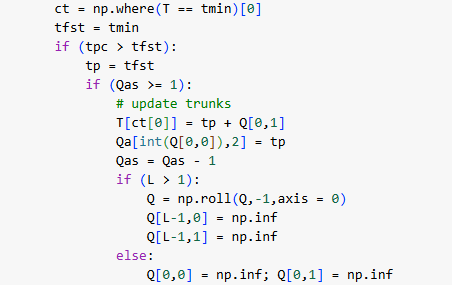
</center>


2. Develop the formula below to obtain the analytical value of the blocking probability of Example 4.

$$ P_{B}=P_{s+n}=\frac{\rho^{s+n}}{s ! S^{n}} P_{0} $$

3. Write a function to analytically calculate the blocking probabilities of the systems shown in Examples 3 and 4 and compare, under the same conditions, with the results obtained in the previous exercise.



# References

1. SEVERANCE, F. L., System Modeling and Simulation, John Wiley & Sons, 2001. (Some figures shown in this lecture are taken from this reference.)